# BHD playground

Playing around with network creation and the bridge-hub detector algorithm.

In [63]:
import numpy as np   
import matplotlib.pyplot as plt
import networkx as nx

#EPIDEMIC ON NETWORKS 
#https://epidemicsonnetworks.readthedocs.io/en/latest/GettingStarted.html
#FROM the book 
#Mathematics of Epidemics on Networks: from Exact to Approximate Models
#István Z. KissJoel C. MillerPéter L. Simon
#Springer Link

#Install EON
#pip install EoN
import EoN

In [161]:
# create a random test graph via SBM
n = 1000
sizes = [200]* 5
p = np.outer(np.ones(len(sizes)), np.ones(len(sizes))) / n
p += np.diag([0.05]*len(sizes))
G = nx.stochastic_block_model(sizes, p)
# compute modularity
print("Modularity:", nx.algorithms.community.quality.modularity(G, nx.algorithms.community.label_propagation_communities(G)))

Modularity: 0.6569904835701539


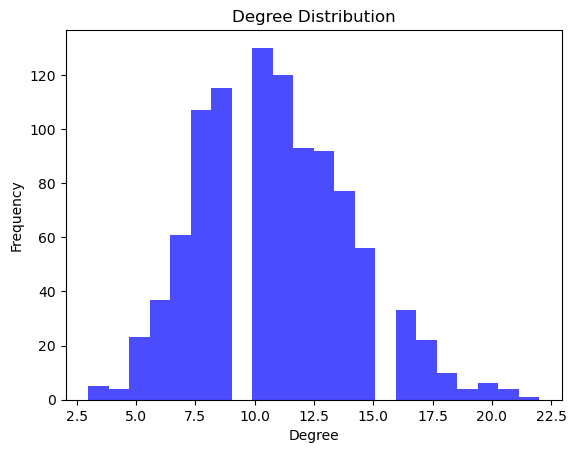

In [171]:
# plot degree distribution
degree_sequence = sorted([d for n, d in G.degree()], reverse=True) 
plt.hist(degree_sequence, bins=22, color='blue', alpha=0.7)
plt.title("Degree Distribution")    
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

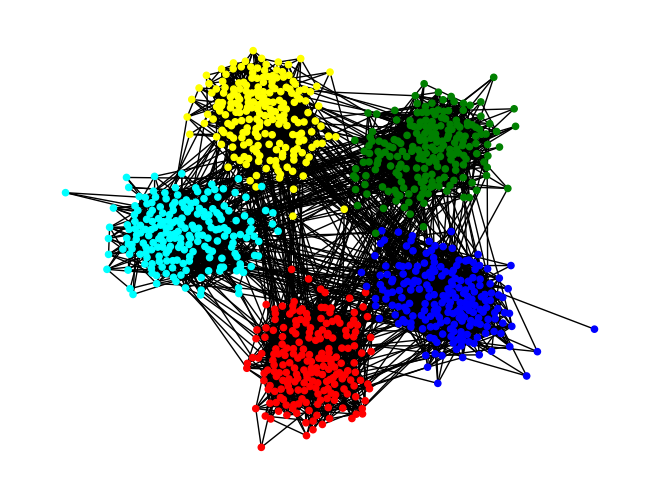

In [149]:
# visualise G and color nodes according to their block
color_map = []
for node in G.nodes():
    if node < 200:
        color_map.append('red')
    elif node < 400:
        color_map.append('blue')
    elif node < 600:
        color_map.append('green')
    elif node < 800:
        color_map.append('yellow')
    else:
        color_map.append('cyan')    
nx.draw(G, node_color=color_map, with_labels=False, node_size=20)
plt.show()

### BHD implementation
- Start self-avoiding random walk at random node $v_0$. After each step (past the 2nd one in the RW) do procedure
- $v_t$: RW node at step $t$, $f_t$: set of neighbours of $v_t$, $F_{t-1}= f_0 ∪ f_1 ∪ f_2 ∪ \dots  ∪ f_{t-1}$: Union of friendship circles/neighbours of all previously visited nodes
    - If every other node in $f_t$ already belongs to $F_{t-1}$ or at least has a link to it: $v_t$ not a target -> RW moves on
    - Else, at least one node in $f_t$ not connected to $F_{t-1}$: $v_t$ is immunization target; also random node of $f_t$ that cannot be linked back to $F_{t-1}$ is target -> new RW from random node
- Repeat until desired immunization ratio is achieved
- Terminate walks if no immunization targets found after 20 steps


In [233]:
def BHD(G, immunized_fraction=0.01, maxiter=1000, verbose=False):
    immunized_nodes = set()
    iterations = 0
    nodes = list(G.nodes())

    neighbor_cache = {}  # lazily populated as nodes are visited
    def get_neighbors(n):
        if n not in neighbor_cache:
            neighbor_cache[n] = set(G.neighbors(n))
        return neighbor_cache[n]

    while len(immunized_nodes) < immunized_fraction * G.number_of_nodes() and iterations < maxiter:
        iterations += 1
        RW = set() # nodes visited by the random walk
        F = set() # "friendship circle" (union of neighborhoods of visited nodes)

        # --- 2 steps to initialise the friendship circle ---
        # We just walk and accumulate F, no target checking yet
        node_curr = np.random.choice(nodes) # start at random node
        RW.add(node_curr) # add to RW set
        f_curr = get_neighbors(node_curr) # get neighbors of current node

        if verbose:
            print(f"\nIteration {iterations}: Starting node {node_curr}, neighbors {f_curr}")

        rw_options = f_curr - RW # options for self-avoiding continuation of the walk
        if not rw_options:
            if verbose:
                print(f"No options to continue from node {node_curr}. Restarting walk.")
            continue # if no options, start a new walk
        F.update(f_curr)  # add step 1 neighbourhood to F before moving to step 2
        node_curr = np.random.choice(list(rw_options)) # move to next node
        RW.add(node_curr) # add to RW set
        f_curr = get_neighbors(node_curr) # get neighbors

        if verbose:
            print(f"Step 2: Moved to node {node_curr}, neighbors {f_curr}")

        rw_options = f_curr - RW # options for self-avoiding continuation of the walk
        if not rw_options:
            if verbose:
                print(f"No options to continue from node {node_curr}. Restarting walk.")
            continue # if no options, start a new walk
        F.update(f_curr)  # add step 2 neighbourhood to F before moving to step 3
        node_curr = np.random.choice(list(rw_options)) # move to next node
        RW.add(node_curr) # add to RW set

        # --- Main walk: check for immunization targets ---
        # At this point F contains neighbourhoods of steps 1 and 2,
        # and node_curr is at step 3 — ready for the first check
        restart = False
        while len(RW) < 20 and not restart:
            f_curr = get_neighbors(node_curr) # get neighbors of current node
    
            # Compare f_curr against F_{t-1} (F does NOT yet contain f_curr)
            candidate_nodes = f_curr.difference(F) # candidates are neighbours not yet in the circle F
            immunization_targets = {
                c for c in candidate_nodes # go through candidates
                if not get_neighbors(c).difference({node_curr}).intersection(F) # check if candidate links back to F
            }

            if verbose:
                print(f"At node {node_curr}, neighbors {f_curr}, friendship circle F {F}")
                print(f"Candidate nodes for immunization: {candidate_nodes}")
                print(f"Immunization targets (candidates with no links back to F): {immunization_targets}")

            if immunization_targets: # if we found targets
                immunized_nodes.add(node_curr) # immunize current node
                immunized_nodes.add(np.random.choice(list(immunization_targets))) # immunize random neighbour that doesn't link back
                restart = True # we found a target, so we restart the walk
                if verbose:
                    print(f"Immunized node {node_curr} and target {immunization_targets}. Restarting walk.")
            else:
                if verbose:
                    print(f"No immunization targets found at node {node_curr}. Continuing walk.")
                # Only now add f_curr to F, then advance the walk
                rw_options = f_curr - RW # check for self-avoiding walk options
                if not rw_options:
                    restart = True # if no options, we restart the walk
                    if verbose:
                        print(f"No options to continue from node {node_curr}. Restarting walk.")
                else:
                    F.update(f_curr)  # update circle with current neighbors before moving to next node
                    node_curr = np.random.choice(list(rw_options)) # move to next node
                    RW.add(node_curr) # add to RW set

    return immunized_nodes


Iteration 1: Starting node A3, neighbors {'A2', 'A1', 'A5', 'B', 'A4'}
Step 2: Moved to node B, neighbors {'C1', 'A3'}
At node C1, neighbors {'C4', 'C5', 'S', 'C2', 'B', 'C3'}, friendship circle F {'C1', 'B', 'A2', 'A1', 'A3', 'A4', 'A5'}
Candidate nodes for immunization: {'C4', 'C5', 'S', 'C2', 'C3'}
Immunization targets (candidates with no links back to F): {'C4', 'C5', 'S', 'C2', 'C3'}
Immunized node C1 and target {'C4', 'C5', 'S', 'C2', 'C3'}. Restarting walk.
Immunized: {np.str_('C1'), np.str_('C5')}


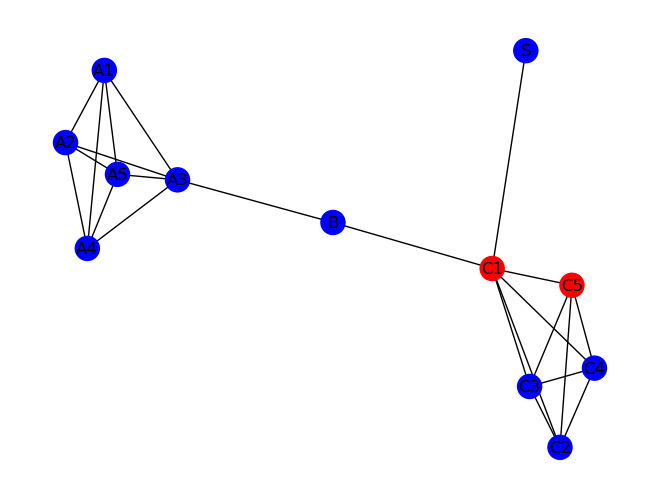

In [234]:
def make_test_graph():
    G = nx.Graph()

    # Community 1: dense clique of 5 nodes
    community1 = ["A1", "A2", "A3", "A4", "A5"]
    for i in range(len(community1)):
        for j in range(i+1, len(community1)):
            G.add_edge(community1[i], community1[j])

    # Community 2: dense clique of 5 nodes
    community2 = ["C1", "C2", "C3", "C4", "C5"]
    for i in range(len(community2)):
        for j in range(i+1, len(community2)):
            G.add_edge(community2[i], community2[j])

    # Bridge-hub node B: connects the two communities
    # B's neighbourhood spans both cliques, so nodes on opposite sides
    # have no links to each other — exactly the BHD target condition
    G.add_edge("B", "A3")   # connects into community 1
    G.add_edge("B", "C1")   # connects into community 2

    # Satellite node S: connected only to C1, no link to B's friendship circle
    # This makes S a valid immunization target when the walk is near B
    G.add_edge("S", "C1")

    return G

G = make_test_graph()

# Run BHD — with 12 nodes, immunized_fraction=0.1 means we need ~1-2 nodes
immunized = BHD(G, immunized_fraction=0.1, maxiter=20, verbose=True)
print("Immunized:", immunized)
# Expected: B should appear, and one of {A-nodes, C-nodes, or S} as the satellite target
color_map = []
for node in G.nodes():
    if node in immunized:
        color_map.append('red')
    else:
        color_map.append('blue')
nx.draw(G, node_color=color_map, with_labels=True, node_size=300)
plt.show()

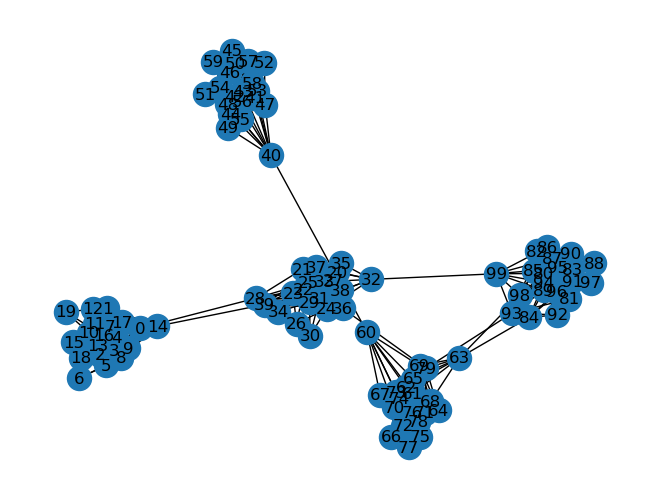

In [235]:
# make a tiny SBM graph and test BHD on it
n = 100
sizes = [20]* 5
p = np.outer(np.ones(len(sizes)), np.ones(len(sizes))) / (4*n)
p += np.diag([0.4]*len(sizes))
G = nx.stochastic_block_model(sizes, p)
nx.draw(G, with_labels=True)
plt.show()

Immunized nodes: {np.int64(0), np.int64(6), np.int64(13), np.int64(14), np.int64(28), np.int64(29), np.int64(32), np.int64(34), np.int64(36), np.int64(39), np.int64(40), np.int64(60), np.int64(62), np.int64(63), np.int64(70), np.int64(79), np.int64(81), np.int64(93), np.int64(98), np.int64(99)}


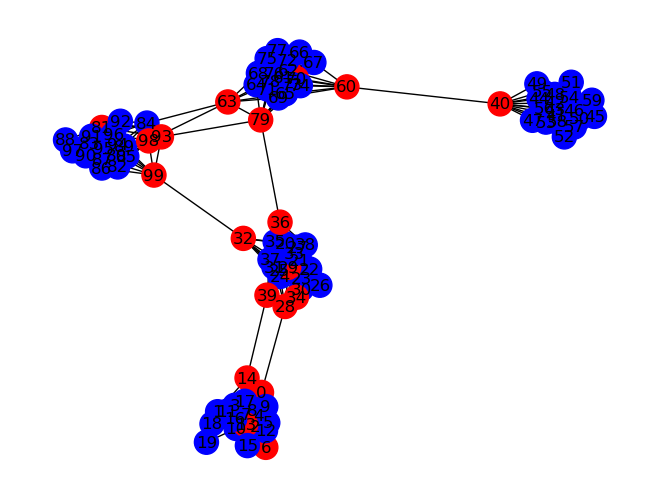

In [236]:
immunized_nodes = BHD(G, immunized_fraction=0.2)
print("Immunized nodes:", immunized_nodes)

# visualise G and highlight immunized nodes
color_map = []
for node in G.nodes():
    if node in immunized_nodes:
        color_map.append('red')
    else:
        color_map.append('blue')
nx.draw(G, node_color=color_map, with_labels=True, node_size=300)
plt.show()

In [240]:
tmax = 100
beta = 0.12 #infection/transmission rate
gamma = 0.2 #recovery rate
#rho = 1/n      #random fraction initially infected
immunized_fraction = 0.01
immunized_nodes = BHD(G, immunized_fraction=immunized_fraction)

#run SIR simulation
results = EoN.fast_SIR(G, beta, gamma, tmax=tmax, initial_recovereds=immunized_nodes, return_full_data = True)

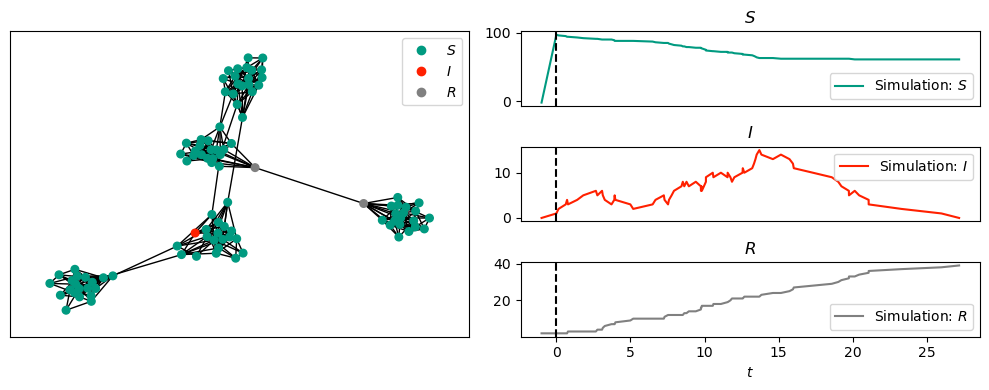

In [241]:
results.display(0, node_size=30)
plt.show()

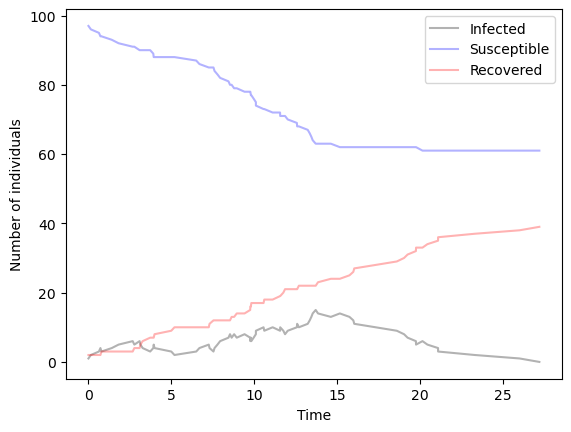

In [242]:
t, S, I, R = results.t(), results.S(), results.I(), results.R()
plt.plot(t[1:], I[1:], color = 'k', alpha=0.3, label='Infected')
plt.plot(t[1:], S[1:], color = 'b', alpha=0.3, label='Susceptible')
plt.plot(t[1:], R[1:], color = 'r', alpha=0.3, label='Recovered')
plt.xlabel('Time')
plt.ylabel('Number of individuals')
plt.legend()
plt.show()

From the EoN Quickstart Guide:

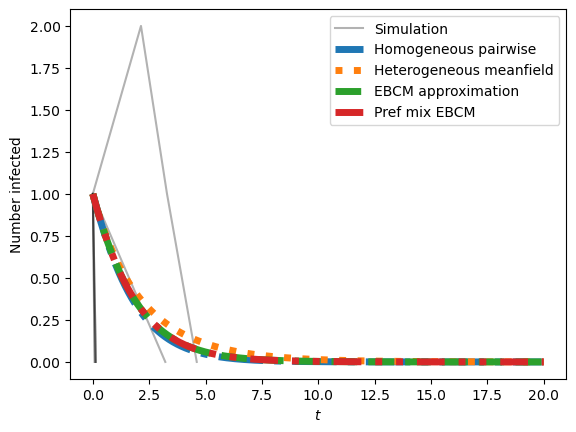

In [99]:
tmax = 20
iterations = 5  #run 5 simulations
tau = 0.1           #infection/transmission rate
gamma = 1.0    #recovery rate
rho = 0.005      #random fraction initially infected

for counter in range(iterations): #run simulations
    t, S, I, R = EoN.fast_SIR(G, tau, gamma, rho=rho, tmax = tmax)
    if counter == 0:
        plt.plot(t, I, color = 'k', alpha=0.3, label='Simulation')
    plt.plot(t, I, color = 'k', alpha=0.3)

#Now compare with ODE predictions.  Read in the degree distribution of G
#and use rho to initialize the various model equations.
#There are versions of these functions that allow you to specify the
#initial conditions rather than starting from a graph.

#we expect a homogeneous model to perform poorly because the degree
#distribution is very heterogeneous
t, S, I, R = EoN.SIR_homogeneous_pairwise_from_graph(G, tau, gamma, rho=rho, tmax = tmax)
plt.plot(t, I, '-.', label = 'Homogeneous pairwise', linewidth = 5)

#meanfield models will generally overestimate SIR growth because they
#treat partnerships as constantly changing.
t, S, I, R = EoN.SIR_heterogeneous_meanfield_from_graph(G, tau, gamma, rho=rho, tmax=tmax)
plt.plot(t, I, ':', label = 'Heterogeneous meanfield', linewidth = 5)

#The EBCM model does not account for degree correlations or clustering
t, S, I, R = EoN.EBCM_from_graph(G, tau, gamma, rho=rho, tmax = tmax)
plt.plot(t, I, '--', label = 'EBCM approximation', linewidth = 5)

#the preferential mixing model captures degree correlations.
t, S, I, R = EoN.EBCM_pref_mix_from_graph(G, tau, gamma, rho=rho, tmax=tmax)
plt.plot(t, I, label = 'Pref mix EBCM', linewidth=5, dashes=[4, 2, 1, 2, 1, 2])

plt.xlabel('$t$')
plt.ylabel('Number infected')

plt.legend()
plt.savefig('SIR_BA_model_vs_sim.png')